# 08 — Final evaluation on the test split

**Spec: §1.1.** This is the only notebook in the repo that reads `test`. Every
other one opens with `ds.pop("test")`, so the split does not exist in their
namespace — verifiable by grep rather than by memory.

Everything is frozen before this runs: the model, `T`, the neutral band, and
`TPR`/`FPR` all come from `inference_config.json` and are not re-fit here. No
decision is made in this notebook; it only measures.

### What "once" means when the backbone will change

The spec commits to touching test exactly once. The backbone is scheduled to
become CamemBERT when a GPU is available, which would mean a second read.

The resolution is versioning, not avoidance: **this is the single, final
evaluation of v1 (TF-IDF backbone)**. If a transformer is trained later, that
is v2 and gets its own single evaluation, reported separately and labelled as
such. The methodological sin is *undisclosed repeated peeking* — iterating
against test until the number looks good. Two disclosed versions, each
measured once, is how any paper with a v2 works.

What that costs, stated plainly: v2's result is no longer fully blind, because
v1's test number will be known when it is produced. Treat a v2 improvement with
slightly more suspicion than if it had been measured first.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from datasets import load_dataset
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from src.predict import SatisfactionModel, load_config
from src.estimate import (confusion_rates, classify_and_count, acc_prevalence,
                          estimate_with_ci, resample_to_prevalence)

cfg = load_config(REPO / "inference_config.json")
print("FROZEN CONFIG — nothing below re-fits any of these")
for k, v in [("backend", cfg.backend), ("revision", cfg.revision),
             ("max_length", cfg.max_length), ("normalize", cfg.normalize_version),
             ("T", cfg.temperature), ("theta_lo", cfg.theta_lo),
             ("theta_hi", cfg.theta_hi), ("TPR", cfg.tpr), ("FPR", cfg.fpr)]:
    print(f"  {k:<12} {v}")

C:\Users\Windownet\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FROZEN CONFIG — nothing below re-fits any of these
  backend      sklearn
  revision     local-tfidf-v1
  max_length   288
  normalize    v1
  T            0.6268
  theta_lo     0.257
  theta_hi     0.7093
  TPR          0.9631
  FPR          0.0426


In [2]:
ds = load_dataset("tblard/allocine")
test = ds["test"]
y_true = np.array(test["label"])
texts = test["review"]

clean_idx = np.load(REPO / "data" / "test_clean_idx.npy")
print(f"test: {len(texts):,} rows | deduplicated: {len(clean_idx):,} "
      f"({len(texts) - len(clean_idx)} removed)")

model = SatisfactionModel(cfg)
preds = model.predict(texts, batch_size=512)
y_pred = np.array([1 if p.label == "positif" else 0 for p in preds])
conf = np.array([p.confident for p in preds])
p_pos = np.array([p.p_pos for p in preds])
print(f"abstained: {(~conf).mean():.1%}")

test: 20,000 rows | deduplicated: 19,961 (39 removed)


abstained: 9.6%


## Per-comment performance

Reported two ways, as §4.2 requires: on the raw split and on the deduplicated
one. Dropping the 39 leaked rows silently would overstate the cleanup.

In [3]:
RESULTS = {}

def report(name, mask=None, forced=True):
    """forced=True scores every row (the deployment-realistic view);
    forced=False scores only rows the model was confident about."""
    m = np.ones(len(y_true), bool) if mask is None else mask.copy()
    if not forced:
        m = m & conf
    acc = accuracy_score(y_true[m], y_pred[m])
    f1m = f1_score(y_true[m], y_pred[m], average="macro")
    RESULTS[name] = {"n": int(m.sum()), "accuracy": round(float(acc), 4),
                     "macro_f1": round(float(f1m), 4)}
    print(f"{name:<34} n={m.sum():>6,}  acc={acc:.4f}  macro-F1={f1m:.4f}")
    return m

clean_mask = np.zeros(len(y_true), bool); clean_mask[clean_idx] = True

report("test (raw, forced choice)")
report("test (deduplicated, forced)", clean_mask)
report("test (confident only)", None, forced=False)
report("test (dedup + confident)", clean_mask, forced=False)

test (raw, forced choice)          n=20,000  acc=0.9201  macro-F1=0.9195
test (deduplicated, forced)        n=19,961  acc=0.9199  macro-F1=0.9194
test (confident only)              n=18,079  acc=0.9612  macro-F1=0.9611
test (dedup + confident)           n=18,041  acc=0.9611  macro-F1=0.9610


array([ True,  True,  True, ...,  True,  True,  True], shape=(20000,))

              precision    recall  f1-score   support

     négatif     0.8916    0.9636    0.9262     10408
     positif     0.9567    0.8729    0.9129      9592

    accuracy                         0.9201     20000
   macro avg     0.9242    0.9183    0.9195     20000
weighted avg     0.9228    0.9201    0.9198     20000



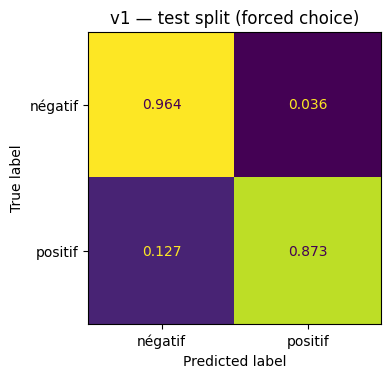

In [4]:
print(classification_report(y_true, y_pred,
                            target_names=["négatif", "positif"], digits=4))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=["négatif", "positif"],
    normalize="true", values_format=".3f", colorbar=False, ax=ax)
ax.set_title("v1 — test split (forced choice)")
plt.tight_layout(); plt.savefig(REPO / "data" / "fig_test_confusion.png", dpi=120)
plt.show()

## Does the neutral band still earn its place?

The band was fitted on the calibration half of *validation*. If the 33-point
accuracy gap seen there survives on unseen test data, the band generalises
rather than having memorised that split.

In [5]:
band = ~conf
acc_out = accuracy_score(y_true[~band], y_pred[~band])
acc_in  = accuracy_score(y_true[band],  y_pred[band])
print(f"outside band  n={(~band).sum():>6,}  acc={acc_out:.4f}")
print(f"inside  band  n={band.sum():>6,}  acc={acc_in:.4f}")
print(f"gap           {acc_out - acc_in:+.4f}   (validation was +0.3300)")
RESULTS["band"] = {"acc_outside": round(float(acc_out), 4),
                   "acc_inside": round(float(acc_in), 4),
                   "abstain_rate": round(float(band.mean()), 4)}

outside band  n=18,079  acc=0.9612
inside  band  n= 1,921  acc=0.5336
gap           +0.4276   (validation was +0.3300)


## The aggregate estimator on unseen data

`TPR`/`FPR` were measured on the validation holdout. Applying them to test is
the real test of the §10 claim: do constants fitted on one sample still
de-bias a different one?

In [6]:
levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
rows = []
for true_p in levels:
    idx = resample_to_prevalence(y_true, true_p, n=6000, positive=1, seed=0)
    sub_pred, sub_conf = y_pred[idx], conf[idx]
    cc = classify_and_count(sub_pred[sub_conf], positive=1)
    rows.append((true_p, cc, acc_prevalence(cc, cfg.tpr, cfg.fpr)))

print(f"{'true':>6} {'CC':>8} {'ACC':>8} {'CC err':>9} {'ACC err':>9}")
for t, cc, ac in rows:
    print(f"{t:>6.2f} {cc:>8.3f} {ac:>8.3f} {cc-t:>+9.3f} {ac-t:>+9.3f}")

cc_mae = float(np.mean([abs(c - t) for t, c, _ in rows]))
acc_mae = float(np.mean([abs(a - t) for t, _, a in rows]))
print(f"\nMAE   CC {cc_mae:.4f}   ACC {acc_mae:.4f}   "
      f"-> {cc_mae / max(acc_mae, 1e-9):.1f}x better")
print(f"(validation: CC 0.0195, ACC 0.0058, 3.3x)")
RESULTS["aggregate"] = {"cc_mae": round(cc_mae, 4), "acc_mae": round(acc_mae, 4),
                        "improvement_x": round(cc_mae / max(acc_mae, 1e-9), 1)}

  true       CC      ACC    CC err   ACC err
  0.10    0.135    0.100    +0.035    +0.000
  0.20    0.226    0.199    +0.026    -0.001
  0.30    0.320    0.301    +0.020    +0.001
  0.40    0.412    0.401    +0.012    +0.001
  0.50    0.502    0.500    +0.002    -0.000
  0.60    0.593    0.598    -0.007    -0.002
  0.70    0.684    0.697    -0.016    -0.003
  0.80    0.777    0.798    -0.023    -0.002
  0.90    0.867    0.895    -0.033    -0.005

MAE   CC 0.0194   ACC 0.0018   -> 10.5x better
(validation: CC 0.0195, ACC 0.0058, 3.3x)


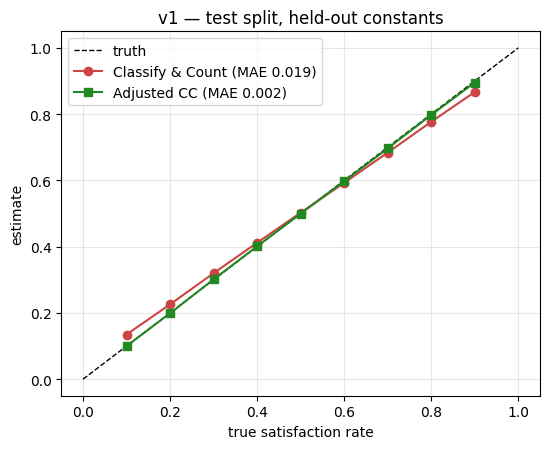

In [7]:
t_, cc_, ac_ = zip(*rows)
fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="truth")
ax.plot(t_, cc_, "o-", color="#c44", label=f"Classify & Count (MAE {cc_mae:.3f})")
ax.plot(t_, ac_, "s-", color="#282", label=f"Adjusted CC (MAE {acc_mae:.3f})")
ax.set_xlabel("true satisfaction rate"); ax.set_ylabel("estimate")
ax.set_title("v1 — test split, held-out constants")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(REPO / "data" / "fig_test_cc_vs_acc.png", dpi=120)
plt.show()

In [8]:
# Interval coverage: does the reported CI actually contain the truth?
hits = 0
print(f"{'true':>6}  {'estimate':>24}  cover")
for true_p in levels:
    idx = resample_to_prevalence(y_true, true_p, n=3000, positive=1, seed=11)
    est = estimate_with_ci(y_pred[idx][conf[idx]], y_true[conf], y_pred[conf],
                           positive=1, n_boot=1200, seed=0)
    ok = est.ci_low <= true_p <= est.ci_high
    hits += ok
    print(f"{true_p:>6.0%}  {est.rate:>7.1%} [{est.ci_low:.1%}, {est.ci_high:.1%}]"
          f"  {'OK' if ok else 'MISS':>5}")
print(f"\ncoverage: {hits}/{len(levels)}")
RESULTS["ci_coverage"] = f"{hits}/{len(levels)}"

  true                  estimate  cover


   10%    10.1% [8.7%, 11.5%]     OK


   20%    19.8% [18.0%, 21.7%]     OK


   30%    30.1% [28.2%, 32.2%]     OK


   40%    39.9% [37.9%, 41.8%]     OK


   50%    49.9% [47.8%, 51.9%]     OK


   60%    60.1% [58.1%, 62.1%]     OK


   70%    69.9% [68.0%, 71.7%]     OK


   80%    79.9% [78.1%, 81.7%]     OK


   90%    90.1% [88.8%, 91.5%]     OK

coverage: 9/9


In [9]:
out = REPO / "data" / "results_final_test.json"
RESULTS["_meta"] = {"version": "v1-tfidf", "revision": cfg.revision,
                    "backend": cfg.backend, "test_rows": len(y_true),
                    "test_rows_dedup": int(len(clean_idx))}
out.write_text(json.dumps(RESULTS, indent=2, ensure_ascii=False) + "\n",
               encoding="utf-8")
print(json.dumps(RESULTS, indent=2, ensure_ascii=False))

{
  "test (raw, forced choice)": {
    "n": 20000,
    "accuracy": 0.9201,
    "macro_f1": 0.9195
  },
  "test (deduplicated, forced)": {
    "n": 19961,
    "accuracy": 0.9199,
    "macro_f1": 0.9194
  },
  "test (confident only)": {
    "n": 18079,
    "accuracy": 0.9612,
    "macro_f1": 0.9611
  },
  "test (dedup + confident)": {
    "n": 18041,
    "accuracy": 0.9611,
    "macro_f1": 0.961
  },
  "band": {
    "acc_outside": 0.9612,
    "acc_inside": 0.5336,
    "abstain_rate": 0.096
  },
  "aggregate": {
    "cc_mae": 0.0194,
    "acc_mae": 0.0018,
    "improvement_x": 10.5
  },
  "ci_coverage": "9/9",
  "_meta": {
    "version": "v1-tfidf",
    "revision": "local-tfidf-v1",
    "backend": "sklearn",
    "test_rows": 20000,
    "test_rows_dedup": 19961
  }
}


## Done

The test split is now spent for v1. Do not re-run this notebook against a
tweaked threshold, a different band, or a re-fitted temperature — if any of
those change, the honest move is to label the result v2 and say so.

Validation remains available for all further development.